In [12]:
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
X_train = joblib.load("../data/processed/X_train.pkl")
X_val = joblib.load("../data/processed/X_val.pkl")
X_test = joblib.load("../data/processed/X_test.pkl")

y_train = joblib.load("../data/processed/y_train.pkl")
y_val = joblib.load("../data/processed/y_val.pkl")
y_test = joblib.load("../data/processed/y_test.pkl")

In [4]:
label_encoder = joblib.load("../models/disease_label_encoder.pkl")

In [5]:
num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)

Number of classes: 659


In [6]:
model = Sequential([
    Dense(256, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(num_classes, activation="softmax")
])

c:\Users\Acer\.conda\envs\co\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        84,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 659)            │        42,835 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 504,635 (1.93 MB)

 Trainable params: 168,211 (657.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 336,424 (1.28 MB)

In [8]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=128,
    verbose=1
)

Epoch 1/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.6320 - loss: 1.6633 - val_accuracy: 0.7847 - val_loss: 0.6643
Epoch 2/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8024 - loss: 0.5842 - val_accuracy: 0.8048 - val_loss: 0.5518
Epoch 3/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8166 - loss: 0.5076 - val_accuracy: 0.8099 - val_loss: 0.5207
Epoch 4/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8236 - loss: 0.4718 - val_accuracy: 0.8141 - val_loss: 0.5004
Epoch 5/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8285 - loss: 0.4520 - val_accuracy: 0.8171 - val_loss: 0.4779
Epoch 6/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8303 - loss: 0.4390 - val_accuracy: 0.8190 - val_loss: 0.4742
Epoch 7/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8327 - loss: 0.4282 - val_accuracy: 0.8179 - val_loss: 0.4737
Epoch 8/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8345 - loss: 0.4190 - val_acc

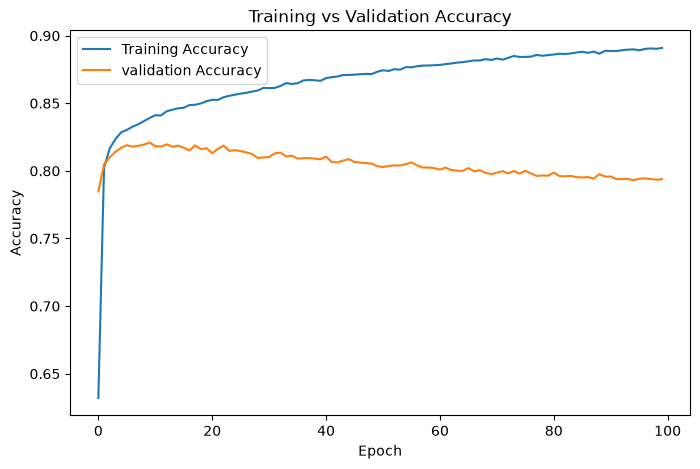

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

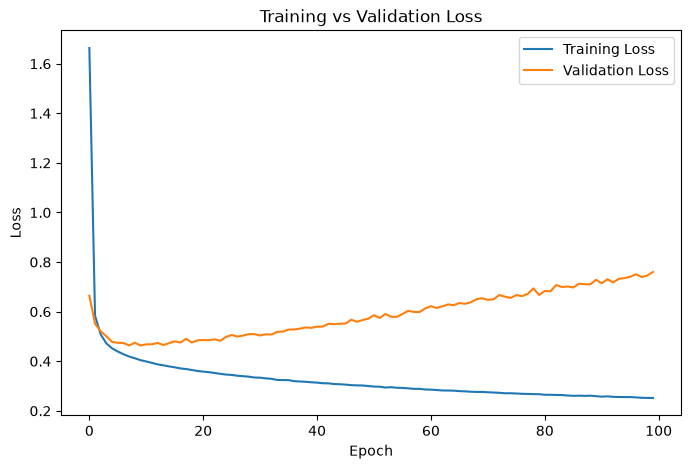

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [15]:
from tensorflow.keras.layers import Dropout

model = Sequential([
    Dense(256, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

c:\Users\Acer\.conda\envs\co\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

In [18]:
early_stopping = EarlyStopping(
     monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [19]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.3619 - loss: 2.8774 - val_accuracy: 0.7211 - val_loss: 1.0349
Epoch 2/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6097 - loss: 1.3731 - val_accuracy: 0.7733 - val_loss: 0.7188
Epoch 3/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.6666 - loss: 1.1267 - val_accuracy: 0.7917 - val_loss: 0.6290
Epoch 4/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.6928 - loss: 1.0147 - val_accuracy: 0.8006 - val_loss: 0.5765
Epoch 5/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7106 - loss: 0.9537 - val_accuracy: 0.8046 - val_loss: 0.5515
Epoch 6/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7193 - loss: 0.9127 - val_accuracy: 0.8089 - val_loss: 0.5353
Epoch 7/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7300 - loss: 0.8748 - val_accuracy: 0.8070 - val_loss: 0.5165
Epoch 8/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7364 - loss: 0.8487 - val_ac

In [20]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [21]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [22]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8009 - loss: 0.5662 - val_accuracy: 0.8263 - val_loss: 0.4166 - learning_rate: 0.0010
Epoch 2/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7998 - loss: 0.5662 - val_accuracy: 0.8245 - val_loss: 0.4173 - learning_rate: 0.0010
Epoch 3/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8000 - loss: 0.5661 - val_accuracy: 0.8278 - val_loss: 0.4157 - learning_rate: 0.0010
Epoch 4/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8000 - loss: 0.5673 - val_accuracy: 0.8263 - val_loss: 0.4152 - learning_rate: 0.0010
Epoch 5/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8006 - loss: 0.5676 - val_accuracy: 0.8282 - val_loss: 0.4132 - learning_rate: 0.0010
Epoch 6/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8023 - loss: 0.5640 - val_accuracy: 0.8276 - val_loss: 0.4133 - learning_rate: 0.0010
Epoch 7/100
948/948 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8014 - loss:

In [24]:
results = model.evaluate(
    X_test,
    y_test
)

print(f"Test Loss:{results[0]}")
print(f"Test Accuracy:{results[1]}")

1185/1185 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8308 - loss: 0.3908
Test Loss:0.3907967805862427
Test Accuracy:0.8308443427085876


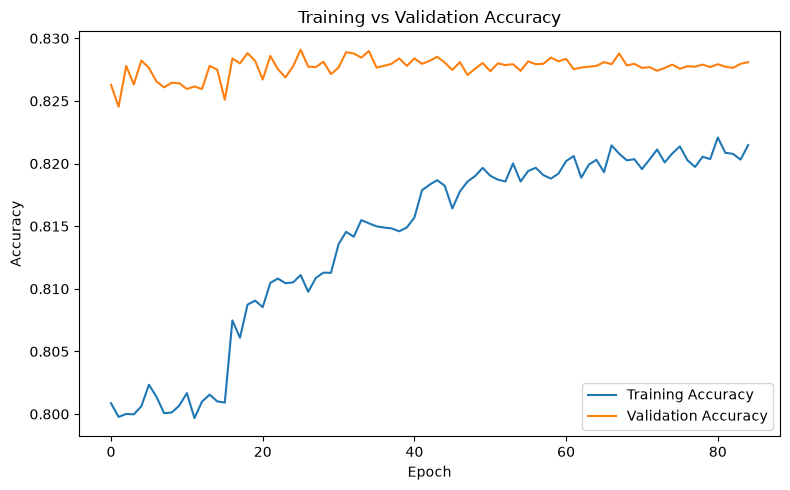

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

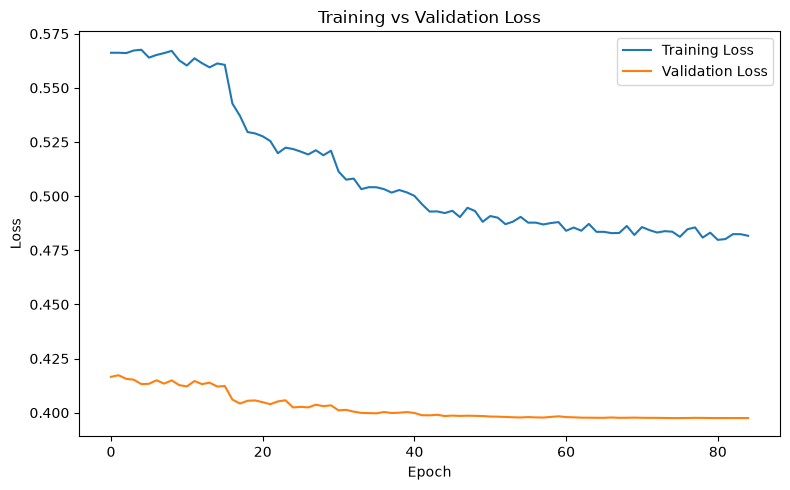

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
model.save("../models/multi_disease_ann.h5")